## Text Preprocessing Pipeline

Raw Steam reviews are noisy and unstructured. They contain URLs, HTML tags, special characters, and highly frequent but meaningless words. Before any NLP analysis can be performed, we transform this raw text into a clean, standardized format.

The dataset contains 931,695 English reviews across 315 games.

**Design Philosophy:**
We follow a minimal removal approach only removing words that are 100% meaningless in any context. Sentiment words, negations, and gaming-specific vocabulary are preserved.

**Two text columns are produced:**

| Column | Purpose | Stopword Strategy |
|---|---|---|
| `review_cleaned` | Notebook 3 EDA & Notebook 4 Topic Modeling | Removes platform meta words |
| `review_cleaned_sentiment` | Notebook 5 Prediction & Sentiment | Identical but also keeps recommend/fun |

**Pipeline Steps:**
* Lowercase
* Remove URLs, HTML tags, special characters
* Tokenize
* Remove stopwords
* Lemmatize
* Reconstruct cleaned string

### Load Notebook 1 Output

We begin by loading the clean base file saved at the end of Notebook 1.
This file contains 931,695 English reviews with all null and junk rows
already removed, so we can proceed directly to preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
tqdm.pandas()

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_parquet('../data/steam_text_mining_base.parquet')

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")

Rows    : 931,695
Columns : ['review_id', 'review', 'recommended', 'votes_helpful', 'written_during_early_access', 'author.playtime_at_review', 'author.num_reviews', 'app_name', 'app_id', 'playtime_hours']


### Downloading the NLTK Resources

NLTK (Natural Language Toolkit) is the core library powering our preprocessing.
We download the required language resources before using them:
- **punkt / punkt_tab**: tokenization models that split text into words
- **stopwords**: a curated list of common English words to remove
- **wordnet / omw-1.4**: vocabulary database used by the lemmatizer
  to map words to their root forms

In [2]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer    = WordNetLemmatizer()
base_stopwords = set(stopwords.words('english'))

print(f"Base stopwords : {len(base_stopwords)}")

Base stopwords : 198


### Define Stopword Lists

We follow a minimal removal philosophy, only removing words that are completely meaningless in any context.

**Three categories of words removed:**

1. **Standard English stopwords** (NLTK): universally meaningless
   function words like "the", "is", "a", "in"

2. **Platform meta words**: words like "steam", "game", "review"
   that appear in virtually every Steam review regardless of topic
   or sentiment, contributing zero discriminative signal

3. **Contraction residuals**: artifacts of apostrophe stripping
   like "im", "ive", "id" that are meaningless on their own

**Deliberately kept:**
* Negation words: "not", "never", "dont", "cant", "wasnt" etc.
  Removing these flips the meaning of reviews entirely.
  Example: "dont recommend" → "recommend" if negations removed.
* Sentiment words: "great", "terrible", "love", "awful" etc.
  These are the primary signal for recommendation prediction.
* Gaming concepts: "multiplayer", "story", "graphics" etc.
  These define the topics we discover in Notebook 4.

The only difference between the two columns is that
`review_cleaned` also removes "recommend" and "fun" since
these are too generic for topic modeling, while
`review_cleaned_sentiment` retains them as sentiment signals.

In [3]:
platform_meta = {
    'game', 'games', 'play', 'played', 'playing',
    'player', 'players', 'steam', 'review', 'reviews',
    'hour', 'hours', 'time', 'get', 'got',
    'one', 'also', 'back', 'way', 'thing', 'things',
    'make', 'made', 'people', 'lot', 'bit',
    'much', 'well', 'still', 'even', 'just',
    'want', 'know', 'think', 'say', 'said',
    'actually', 'would', 'really', 'many', 'every'
}

contraction_residuals = {
    'im', 'ive', 'id', 'wed',
    'youre', 'youve', 'youd', 'youll',
    'theyre', 'theyve', 'theyll',
    'weve', 'hed', 'shed', 'its'
}

negations_to_keep = {
    'not', 'no', 'nor','cannot'
}

base_stopwords = base_stopwords - negations_to_keep


aggressive_extra = {'recommend', 'recommended', 'fun'}

all_stopwords_aggressive = (
    base_stopwords
    .union(platform_meta)
    .union(contraction_residuals)
    .union(aggressive_extra)
)

# Conservative: for Sentiment & Prediction
all_stopwords_conservative = (
    base_stopwords
    .union(platform_meta)
    .union(contraction_residuals)
)

print(f"Aggressive  stopwords : {len(all_stopwords_aggressive)}")
print(f"Conservative stopwords: {len(all_stopwords_conservative)}")

Aggressive  stopwords : 252
Conservative stopwords: 249


### Build Preprocessing Functions

Two functions are define.  One per cleaning strategy. Both follow identical steps, differing only in which stopword list they apply.

The pipeline order is deliberate:
* Lowercasing first ensures case-insensitive matching
* URL/HTML removal before tokenization avoids fragments
* Non-alphabetic removal strips numbers and symbols
* Stopword removal and lemmatization at token level
* Tokens shorter than 2 characters removed as noise

In [4]:
def preprocess_aggressive(text):
    text   = text.lower()
    text   = re.sub(r'http\S+|www\S+', '', text)
    text   = re.sub(r'<.*?>', '', text)
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens
              if t not in all_stopwords_aggressive and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


def preprocess_conservative(text):
    text   = text.lower()
    text   = re.sub(r'http\S+|www\S+', '', text)
    text   = re.sub(r'<.*?>', '', text)
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens
              if t not in all_stopwords_conservative and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


print("preprocess_aggressive()  : for EDA & Topic Modeling")
print("preprocess_conservative(): for Sentiment & Prediction")

preprocess_aggressive()  : for EDA & Topic Modeling
preprocess_conservative(): for Sentiment & Prediction


### Test Both Pipelines on Real Reviews

We test both functions on the same 3 real reviews before applying them to the full dataset. This confirms:
1. Noise is correctly removed
2. Negation words are preserved in both versions
3. Conservative version retains more sentiment vocabulary
4. No meaningful content is accidentally removed

In [5]:
test_reviews = [
    "I dont recommend this game, it wasnt fun at all",
    df['review'].sample(1, random_state=42).values[0],
    df['review'].sample(1, random_state=99).values[0],
]

print("=" * 70)
for i, review in enumerate(test_reviews, 1):
    agg  = preprocess_aggressive(review)
    cons = preprocess_conservative(review)
    print(f"\n--- Review {i} ---")
    print(f"ORIGINAL     ({len(review.split())} words):\n{review[:300]}")
    print(f"\nAGGRESSIVE   ({len(agg.split())} words):\n{agg[:300]}")
    print(f"\nCONSERVATIVE ({len(cons.split())} words):\n{cons[:300]}")
    print("=" * 70)


--- Review 1 ---
ORIGINAL     (10 words):
I dont recommend this game, it wasnt fun at all

AGGRESSIVE   (2 words):
dont wasnt

CONSERVATIVE (4 words):
dont recommend wasnt fun

--- Review 2 ---
ORIGINAL     (15 words):
It nicely fills that itch for a good co-op shooter while still being enjoyable solo.

AGGRESSIVE   (8 words):
nicely fill itch good coop shooter enjoyable solo

CONSERVATIVE (8 words):
nicely fill itch good coop shooter enjoyable solo

--- Review 3 ---
ORIGINAL     (12 words):
Entretaining. I am enjoying it. UI needs a tiny bit of help.

AGGRESSIVE   (5 words):
entretaining enjoying need tiny help

CONSERVATIVE (5 words):
entretaining enjoying need tiny help


### Apply Both Pipelines to Full Dataset

We apply both functions to all 931,695 reviews. Results are stored in two new columns, keeping the original review intact.

In [6]:
print("Pass 1/2: Aggressive pipeline (EDA & Topic Modeling)...")
df['review_cleaned'] = df['review'].progress_apply(preprocess_aggressive)
print(f"Pass 1 complete\n")

print("Pass 2/2: Conservative pipeline (Sentiment & Prediction)...")
df['review_cleaned_sentiment'] = df['review'].progress_apply(preprocess_conservative)
print(f"Pass 2 complete")

print(f"\nBoth pipelines applied")
print(f"Total rows processed : {len(df):,}")

Pass 1/2: Aggressive pipeline (EDA & Topic Modeling)...


100%|██████████| 931695/931695 [01:26<00:00, 10754.72it/s]


Pass 1 complete

Pass 2/2: Conservative pipeline (Sentiment & Prediction)...


100%|██████████| 931695/931695 [01:27<00:00, 10629.85it/s]

Pass 2 complete

Both pipelines applied
Total rows processed : 931,695


### Post-Cleaning Validation

After preprocessing, some reviews may have become empty. These were reviews containing nothing beyond URLs, symbols,
numbers, or stopwords. We remove them and document how many were dropped.

We check both columns and drop any row where either version produced an empty result.

In [7]:
empty_aggressive   = df['review_cleaned'].str.strip().str.len() == 0
empty_conservative = df['review_cleaned_sentiment'].str.strip().str.len() == 0

print(f"Empty after aggressive cleaning   : {empty_aggressive.sum():,}")
print(f"Empty after conservative cleaning : {empty_conservative.sum():,}")

drop_mask = empty_aggressive | empty_conservative
df = df[~drop_mask].copy()

print(f"\nRows remaining : {len(df):,}")

Empty after aggressive cleaning   : 12,612
Empty after conservative cleaning : 6,987

Rows remaining : 919,083


### Compare Review Lengths Across All Three Versions

We compute word counts for raw, aggressive, and conservative versions to quantify the impact of each pipeline and confirm the conservative version retains more words than aggressive.

In [8]:
df['word_count_raw']          = df['review'].str.split().str.len()
df['word_count_cleaned']      = df['review_cleaned'].str.split().str.len()
df['word_count_conservative'] = df['review_cleaned_sentiment'].str.split().str.len()

print("Word Count Comparison")
print(pd.DataFrame({
    'Raw'          : df['word_count_raw'].describe(),
    'Aggressive'   : df['word_count_cleaned'].describe(),
    'Conservative' : df['word_count_conservative'].describe()
}).round(2))

agg_removed = (df['word_count_raw'] - df['word_count_cleaned']).mean()
con_removed = (df['word_count_raw'] - df['word_count_conservative']).mean()
agg_pct     = agg_removed / df['word_count_raw'].mean() * 100
con_pct     = con_removed / df['word_count_raw'].mean() * 100

print(f"\nAggressive  : avg words removed : {agg_removed:.1f} ({agg_pct:.1f}%)")
print(f"Conservative  : avg words removed : {con_removed:.1f} ({con_pct:.1f}%)")

Word Count Comparison
             Raw  Aggressive  Conservative
count  919083.00   919083.00     919083.00
mean       48.89       20.42         20.73
std       100.76       44.08         44.29
min         3.00        1.00          1.00
25%         7.00        3.00          3.00
50%        17.00        7.00          7.00
75%        46.00       19.00         19.00
max      2663.00     2000.00       2000.00

Aggressive  : avg words removed : 28.5 (58.2%)
Conservative  : avg words removed : 28.2 (57.6%)


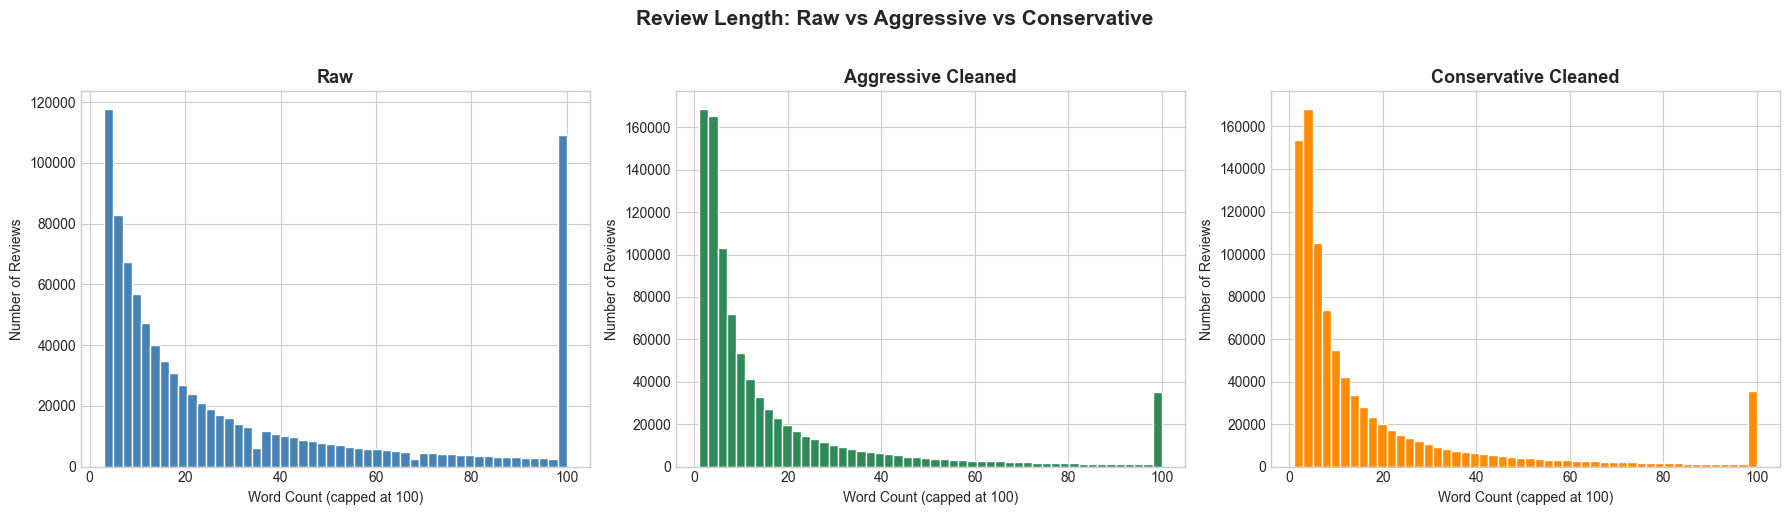

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (df['word_count_raw'],          'Raw',                  'steelblue'),
    (df['word_count_cleaned'],      'Aggressive Cleaned',   'seagreen'),
    (df['word_count_conservative'], 'Conservative Cleaned', 'darkorange'),
]

for ax, (data, title, color) in zip(axes, configs):
    ax.hist(data.clip(upper=100), bins=50,
            color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Word Count (capped at 100)')
    ax.set_ylabel('Number of Reviews')

plt.suptitle('Review Length: Raw vs Aggressive vs Conservative',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Save Notebook 2 Checkpoint

We save the fully preprocessed dataset containing all three text versions
as a parquet file before proceeding to Notebook 3.

This checkpoint ensures neither preprocessing pass needs to be re-run.
All subsequent Notebooks load directly from this file and use the
appropriate text column for their specific task.

| Column | Purpose |
|---|---|
| `review` | Original raw text - always preserved for reference |
| `review_cleaned` | Aggressive cleaning - Notebook 3 EDA & Notebook 4 Topic Modeling |
| `review_cleaned_sentiment` | Conservative cleaning - Notebook 5 Prediction & Sentiment |

In [10]:
output_path = '../data/steam_text_mining_nb2.parquet'
df.to_parquet(output_path, index=False)

print(f"Notebook 2 checkpoint saved : steam_text_mining_ch2.parquet")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")
print(f"Size    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Notebook 2 checkpoint saved : steam_text_mining_ch2.parquet
Rows    : 919,083
Columns : ['review_id', 'review', 'recommended', 'votes_helpful', 'written_during_early_access', 'author.playtime_at_review', 'author.num_reviews', 'app_name', 'app_id', 'playtime_hours', 'review_cleaned', 'review_cleaned_sentiment', 'word_count_raw', 'word_count_cleaned', 'word_count_conservative']
Size    : 625.2 MB


## Data preprocessing Summary

| Step | Detail |
|---|---|
| Rows loaded | 931,695 |
| Lowercasing | All text normalized to lowercase |
| Noise removal | URLs, HTML tags, non-alphabetic characters removed |
| Tokenization | NLTK word_tokenize |
| Aggressive stopwords | 252 total |
| Conservative stopwords | 249 total |
| Lemmatization | NLTK WordNetLemmatizer |
| Reviews dropped (became empty) | 12,612 |
| Aggressive - avg words removed | ~29 words (~58%) |
| Conservative - avg words removed | ~28 words (~57%) |
| Final rows after cleaning | 919,083 |

**Key Design Decision: Two Cleaning Versions:**

A single preprocessing approach cannot serve all NLP tasks optimally. So, we produced two cleaned text columns with different stopword strategies:

1. **`review_cleaned` (Aggressive):** Removes all gaming filler and generic sentiment words. Used for Notebook 3 EDA and Notebook 4 Topic Modeling where thematic clarity is the priority.

2. **`review_cleaned_sentiment` (Conservative):** Retains sentiment-bearing words like 'great', 'terrible', 'awful', 'recommend'. Used for Notebook 5 where these words are the primary signal for predicting positive vs negative recommendations.

**Key Observations:**

1. **Noise Reduction:** The aggressive pipeline removed ~58% of words on average. The conservative pipeline removed ~57%, retaining more sentiment-bearing vocabulary as intended.

2. **Minimal Data Loss:** Only 12,612 reviews were discarded post-cleaning, confirming the vast majority of reviews contained substantive content.

3. **Median is More Representative:** Due to the presence of very long reviews (max: 2,663 words raw), the mean word count is skewed upward. The median word count better represents the typical review length.

**Output:** `steam_text_mining_nb2.parquet`